LAB 4: BÀI THỰC HÀNH CHUẨN BỊ DỮ LIỆU

PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING

Viết hàm load_data() để tải dữ liệu lên ứng dụng. Sau đó, hiển thị ra màn hình 10 dòng đầu tiên.

In [3]:
import pandas as pd

def load_data(file_path):
    try:
        # Tải dữ liệu dữ liệu lên ứng dụng
        data = pd.read_csv(file_path)
        print("Tải dữ liệu thành công!")
        return data
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy file tại đường dẫn '{file_path}'")
        return None

file_name = "titanic_disaster.csv"

# Gọi hàm để tải dữ liệu
df = load_data(file_name)

# Nếu tải dữ liệu thành công, hiển thị 10 dòng đầu tiên
if df is not None:
    print("\n10 dòng đầu tiên của dữ liệu:")
    print(df.head(10))

Tải dữ liệu thành công!

10 dòng đầu tiên của dữ liệu:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6        

2. Thống kê dữ liệu thiếu trên các biến số và trực quan hóa dữ liệu thiếu bằng biểu đồ (Heat 
map). Hãy cho nhận xét về tình trạng thiếu dữ liệu Age, Cabin và Embarked

BẢNG THỐNG KÊ DỮ LIỆU THIẾU:
          Số lượng thiếu  Tỷ lệ (%)
Cabin                687      77.10
Age                  177      19.87
Embarked               2       0.22


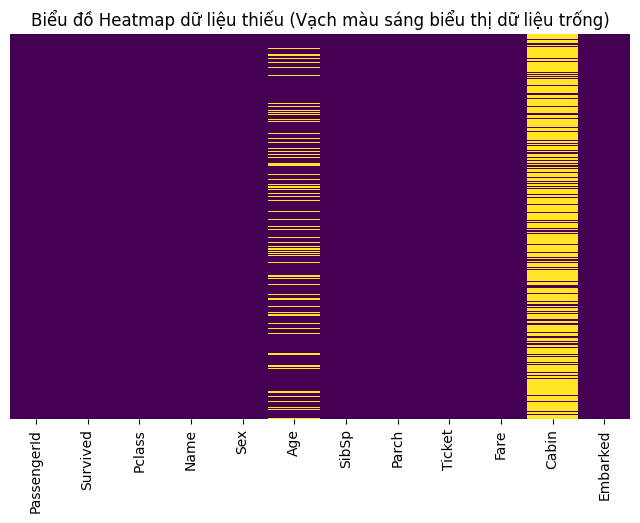

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Thống kê số lượng và tỷ lệ % dữ liệu thiếu
missing_df = pd.DataFrame({
    'Số lượng thiếu': df.isnull().sum(),
    'Tỷ lệ (%)': (df.isnull().sum() / len(df)) * 100
}).loc[df.isnull().any()].sort_values(by='Số lượng thiếu', ascending=False)

print("BẢNG THỐNG KÊ DỮ LIỆU THIẾU:")
print(missing_df.round(2))

# Vẽ biểu đồ Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Biểu đồ Heatmap dữ liệu thiếu (Vạch màu sáng biểu thị dữ liệu trống)')
plt.show()

Cabin (Số phòng): Thiếu rất nghiêm trọng (~77%). Cột biểu đồ bị trống phần lớn. Thông tin quá ít, hướng xử lý thường là loại bỏ cột này hoặc chuyển đổi thành biến phân loại (Có/Không có cabin).

Age (Tuổi): Thiếu ở mức vừa phải (~20%). Các vạch trống nằm rải rác. Đây là biến quan trọng nên cần giữ lại và xử lý bằng cách điền khuyết (thay thế bằng tuổi trung vị hoặc trung bình theo nhóm).

Embarked (Cảng lên tàu): Thiếu rất ít (chỉ 2 dòng, ~0.2%). Gần như không thấy vạch thiếu trên biểu đồ. Có thể dễ dàng xử lý bằng cách điền giá trị xuất hiện nhiều nhất (Mode) hoặc xóa bỏ 2 dòng này

3. Xử lý tên cột tên Name, tách ra làm 2 cột: firstName và secondName. Lưu ý: Sau khi tách cột xong thì xóa luôn cột Name

In [7]:
df[['secondName', 'firstName']] = df['Name'].str.split(',', n=1, expand=True)

df['firstName'] = df['firstName'].str.strip()
df['secondName'] = df['secondName'].str.strip()

df.drop(columns=['Name'], inplace=True)

# 4. Hiển thị lại 5 dòng đầu tiên để kiểm tra kết quả
print("Dữ liệu sau khi tách cột Name và xóa cột gốc:")
df[['firstName', 'secondName']].head()

Dữ liệu sau khi tách cột Name và xóa cột gốc:


,firstName,secondName
0,Mr. Owen Harris,Braund
1,Mrs. John Bradley (Florence Briggs Thayer),Cumings
2,Miss. Laina,Heikkinen
3,Mrs. Jacques Heath (Lily May Peel),Futrelle
4,Mr. William Henry,Allen


4. Xứ lý rút gọn kích thước dữ liệu trên cột Sex như sau: thay thế male → M và female → F

In [8]:
df['Sex'] = df['Sex'].map({'male': 'M', 'female': 'F'})

print("Dữ liệu cột Sex sau khi được rút gọn:")
df[['Sex']].head()

Dữ liệu cột Sex sau khi được rút gọn:


,Sex
0,M
1,F
2,F
3,F
4,M


5. Xử lý dữ liệu thiếu trên biến Age bằng cách thay thế bằng giá trị trung bình tuổi: Hãy đưa ra quyết định dùng giá trị trung bình tuổi toàn bộ hành khách hay theo từng nhóm hạng vé (hạng hành khách: Pclass). Ta tiến hành làm các bước sau
a. Sử dụng Seaborn để vẽ biểu đồ (Box plot) trực quan dữ liệu để xác định phân phối tuổi trên từng hạng hành khách. Nhận xét về tuổi trung bình giữa các nhóm hành khách. Từ đó đưa ra quyết định cách thay thế giá trị tuổi bị thiếu.

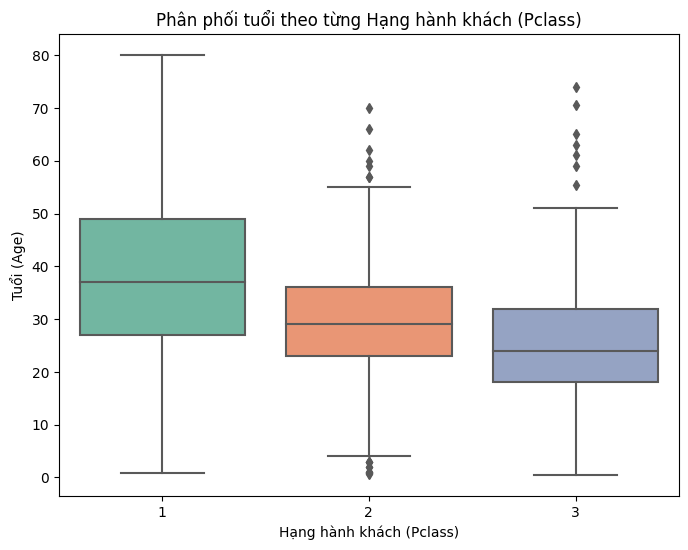

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='Pclass', y='Age', data=df, palette='Set2')

plt.title('Phân phối tuổi theo từng Hạng hành khách (Pclass)')
plt.xlabel('Hạng hành khách (Pclass)')
plt.ylabel('Tuổi (Age)')
plt.show()

b. Tiến hành thay thế giá trị Age bị thiếu. Sau đó, hiển thị kết quả dạng bảng và trực 
quan dữ liệu đã xử lý thiếu cho cột’Age’ bằng biểu đồ Heat map.

Tuổi trung bình theo từng hạng vé:
Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

Số lượng dòng thiếu trên cột 'Age' sau khi xử lý: 0


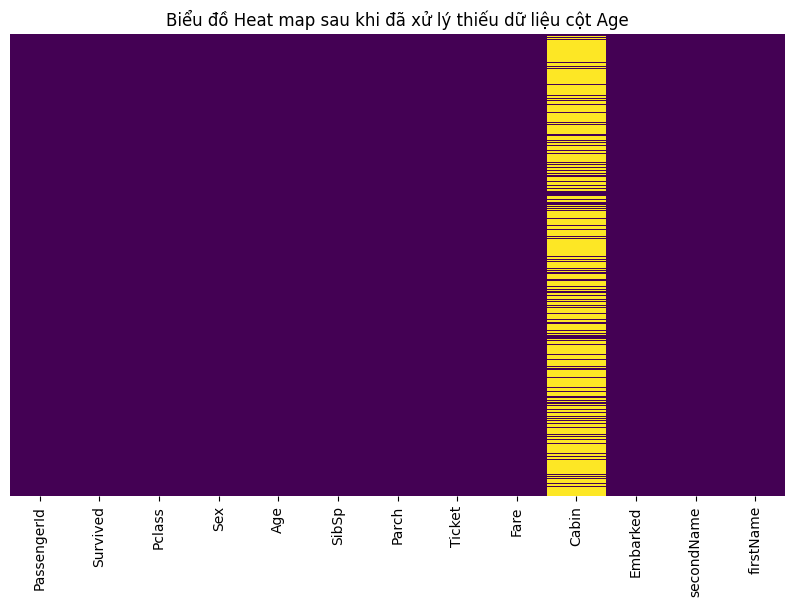

In [12]:
age_by_pclass = df.groupby('Pclass')['Age'].mean()
print("Tuổi trung bình theo từng hạng vé:")
print(age_by_pclass)

def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    
    # Nếu giá trị Age bị trống (null)
    if pd.isnull(Age):
        if Pclass == 1:
            return age_by_pclass[1]
        elif Pclass == 2:
            return age_by_pclass[2]
        else:
            return age_by_pclass[3]
    else:
        return Age

df['Age'] = df[['Age', 'Pclass']].apply(impute_age, axis=1)

missing_after = df[['Age']].isnull().sum()
print("\nSố lượng dòng thiếu trên cột 'Age' sau khi xử lý:", missing_after['Age'])

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Biểu đồ Heat map sau khi đã xử lý thiếu dữ liệu cột Age')
plt.show()

6. Xây dựng biến số Agegroup có thang đo thứ tự được ánh xạ theo thang đo khoảng dựa 
trên độ tuổi của hành khách như sau: (age =< 12] → Kid; (12, 18]: Teen, (18, 60]: Adult 
và ( age > 60): Older

In [13]:
bins = [-1, 12, 18, 60, float('inf')]
labels = ['Kid', 'Teen', 'Adult', 'Older']

df['Agegroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

print("Kết quả phân nhóm tuổi hành khách:")
df[['Age', 'Agegroup']].sample(10, random_state=42)

Kết quả phân nhóm tuổi hành khách:


,Age,Agegroup
709,25.14062,Adult
439,31.00000,Adult
840,20.00000,Adult
720,6.00000,Kid
39,14.00000,Teen
290,26.00000,Adult
300,25.14062,Adult
333,16.00000,Teen
208,16.00000,Teen
136,19.00000,Adult


7. Tiến hành thêm đặc trưng về danh xưng (namePrefix) trong xã hội bằng cách tách Mr, Mrs, Miss, Master ra khỏi “secondName”

In [14]:
df[['namePrefix', 'restOfName']] = df['firstName'].str.split('.', n=1, expand=True)

# 2. Làm sạch khoảng trắng thừa ở đầu và cuối chuỗi vừa tách
df['namePrefix'] = df['namePrefix'].str.strip()

# 3. Xóa cột trung gian không cần thiết (nếu muốn giữ sạch bảng dữ liệu)
df.drop(columns=['restOfName'], inplace=True)

# 4. Hiển thị bảng thống kê các loại danh xưng vừa tách được để kiểm tra kết quả
print("Các danh xưng tách được và số lượng tương ứng:")
print(df['namePrefix'].value_counts())

# 5. Hiển thị 5 dòng đầu tiên của các cột liên quan để kiểm tra trực quan
print("\nKiểm tra ngẫu nhiên kết quả sau khi tách:")
df[['namePrefix', 'firstName']].head()

Các danh xưng tách được và số lượng tương ứng:
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: namePrefix, dtype: int64

Kiểm tra ngẫu nhiên kết quả sau khi tách:


,namePrefix,firstName
0,Mr,Mr. Owen Harris
1,Mrs,Mrs. John Bradley (Florence Briggs Thayer)
2,Miss,Miss. Laina
3,Mrs,Mrs. Jacques Heath (Lily May Peel)
4,Mr,Mr. William Henry


8. Khai thác thêm thông tin số lượng thành viên đi theo nhóm thân quen (familySize) đối với mỗi hành khách trên chuyến hải trình; family size = 1+ SibSp + Parch

In [16]:

df['familySize'] = 1 + df['SibSp'] + df['Parch']

print("Thống kê số lượng hành khách theo quy mô gia đình (familySize):")
print(df['familySize'].value_counts().sort_index())

print("\nKiểm tra trực quan kết quả:")
df[['SibSp', 'Parch', 'familySize']].head()

Thống kê số lượng hành khách theo quy mô gia đình (familySize):
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: familySize, dtype: int64

Kiểm tra trực quan kết quả:


,SibSp,Parch,familySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


9. Tạo thêm đặc trưng ‘Alone’ để xác định hành khách đi theo nhóm hay cá nhân bằng cách dựa trên familySize như sau: Nếu familySize = 0 thì giá trị Alone = 1 và ngược lại là 0

In [17]:

df['Alone'] = df['familySize'].apply(lambda x: 1 if x == 1 else 0)

# Thống kê số lượng hành khách đi một mình vs đi theo nhóm
print("Thống kê đặc trưng 'Alone' (1: Đi một mình, 0: Đi theo nhóm):")
print(df['Alone'].value_counts())

# Hiển thị trực quan vài dòng để kiểm tra kết quả đối chiếu
print("\nKiểm tra đối chiếu giữa familySize và Alone:")
df[['familySize', 'Alone']].head(10)

Thống kê đặc trưng 'Alone' (1: Đi một mình, 0: Đi theo nhóm):
1    537
0    354
Name: Alone, dtype: int64

Kiểm tra đối chiếu giữa familySize và Alone:


,familySize,Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


10. Tiến hành tách loại cabin (typeCabin) mà hành khách ở để lọc và phân tích đặc tính cabin. Loại cabin được kí hiệu bởi chữ cái đầu tiên. Lưu ý: Đối với dữ liệu cabin bị thiếu thì thay thế bằng “Unknown”

In [19]:
# 1. Xử lý dữ liệu thiếu trên cột Cabin bằng cách thay thế bằng "Unknown"
df['Cabin'] = df['Cabin'].fillna('Unknown')

df['typeCabin'] = df['Cabin'].str[0]

print("Thống kê số lượng theo từng loại Cabin (typeCabin):")
print(df['typeCabin'].value_counts())


Thống kê số lượng theo từng loại Cabin (typeCabin):
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: typeCabin, dtype: int64


PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA

12. Trực quan thông tin tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính.

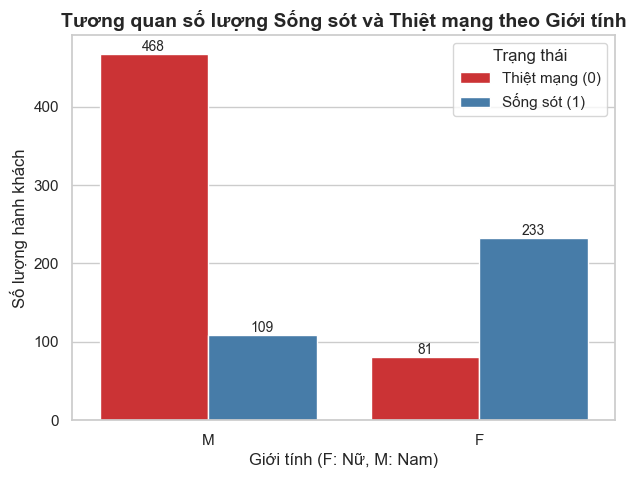

BẢNG TỶ LỆ SỐNG SÓT THEO GIỚI TÍNH:
Survived          0          1
Sex                           
F         25.796178  74.203822
M         81.109185  18.890815


In [22]:
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

ax = sns.countplot(x='Sex', hue='Survived', data=df, palette='Set1')

# Thêm tiêu đề và nhãn
plt.title('Tương quan số lượng Sống sót và Thiệt mạng theo Giới tính', fontsize=14, fontweight='bold')
plt.xlabel('Giới tính (F: Nữ, M: Nam)', fontsize=12)
plt.ylabel('Số lượng hành khách', fontsize=12)
plt.legend(title='Trạng thái', labels=['Thiệt mạng (0)', 'Sống sót (1)'])

# Hiển thị số liệu cụ thể trên đầu mỗi cột để dễ nhận xét
for p in ax.patches:
    if p.get_height() > 0: # Tránh hiển thị các cột rỗng
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 5), 
                    textcoords='offset points', fontsize=10)

plt.show()

# Tính thêm bảng tỷ lệ % chính xác để đưa vào nhận xét
print("BẢNG TỶ LỆ SỐNG SÓT THEO GIỚI TÍNH:")
print(pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100)

Dựa trên biểu đồ trực quan và bảng tỷ lệ thu được, ta rút trích được các thông tin giá trị sau:

Tồn tại sự chênh lệch cực kỳ lớn về cơ hội sống sót giữa hai giới tính: * Đối với Nam giới (M): Số lượng người thiệt mạng chiếm đại đa số. Tỷ lệ thiệt mạng của nam giới lên tới khoảng 80%, trong khi tỷ lệ sống sót chỉ vỏn vẹn khoảng 20%.

Đối với Nữ giới (F): Tình thế hoàn toàn ngược lại. Số lượng nữ giới được cứu sống vượt trội hoàn toàn so với số người thiệt mạng. Tỷ lệ sống sót của nữ giới đạt mức rất cao (khoảng 74-75%).

Bản chất thực tế (Rút trích thông tin giá trị): * Biểu đồ này là minh chứng rõ ràng cho việc thực thi quy tắc đạo đức "Phụ nữ và trẻ em được ưu tiên trước" khi thảm họa Titanic xảy ra.

Giới tính (Sex) là một trong những đặc trưng (feature) quan trọng nhất, mang tính quyết định cao nhất và không thể bỏ qua khi xây dựng các mô hình học máy để dự đoán khả năng sống sót của hành khách trên chuyến tàu này.

13. Trực quan thông tin hành khách sống sót trên từng nhóm phân loại hành khách (Pclass).

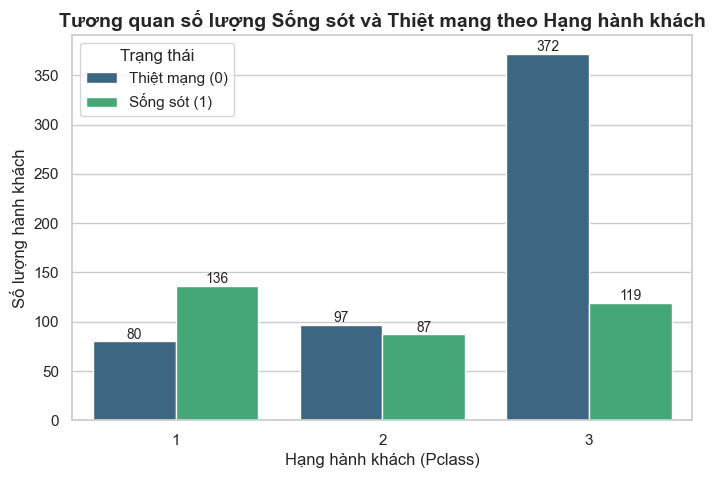

BẢNG TỶ LỆ % SỐNG SÓT THEO HẠNG HÀNH KHÁCH:
Survived      0      1
Pclass                
1         37.04  62.96
2         52.72  47.28
3         75.76  24.24


In [23]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

ax = sns.countplot(x='Pclass', hue='Survived', data=df, palette='viridis')

# Thêm tiêu đề và nhãn cho các trục
plt.title('Tương quan số lượng Sống sót và Thiệt mạng theo Hạng hành khách', fontsize=14, fontweight='bold')
plt.xlabel('Hạng hành khách (Pclass)', fontsize=12)
plt.ylabel('Số lượng hành khách', fontsize=12)
plt.legend(title='Trạng thái', labels=['Thiệt mạng (0)', 'Sống sót (1)'])

# Hiển thị số liệu cụ thể trên từng cột
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 5), 
                    textcoords='offset points', fontsize=10)

plt.show()

# Tính toán bảng tỷ lệ phần trăm chính xác để phục vụ nhận xét
print("BẢNG TỶ LỆ % SỐNG SÓT THEO HẠNG HÀNH KHÁCH:")
pclass_surv = pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100
print(pclass_surv.round(2))

Tỷ lệ sống sót tỷ lệ nghịch với số hạng vé (Hạng vé càng cao, cơ hội sống sót càng lớn):

Hạng 1 (Pclass 1 - Thượng lưu): Đây là nhóm duy nhất có số người sống sót nhiều hơn số người thiệt mạng. Tỷ lệ sống sót đạt mức cao nhất (khoảng 63%).

Hạng 2 (Pclass 2 - Trung lưu): Tỷ lệ sống sót ở mức trung bình (khoảng 47%), số người sống sót và thiệt mạng gần như tương đương nhau.

Hạng 3 (Pclass 3 - Bình dân/Bình dân di cư): Đây là nhóm chịu tổn thất nặng nề nhất. Số lượng người thiệt mạng áp đảo hoàn toàn, tỷ lệ thiệt mạng lên tới khoảng 76%, đồng nghĩa với việc chỉ có khoảng 24% hành khách hạng này may mắn sống sót.

Bản chất thực tế (Rút trích thông tin giá trị):

Thảm họa Titanic không chỉ chịu tác động bởi yếu tố đạo đức (ưu tiên phụ nữ, trẻ em) mà còn bị ảnh hưởng sâu sắc bởi vị thế kinh tế - xã hội (Socioeconomic status).

Nguyên nhân một phần đến từ vị trí địa lý của các khoang tàu: phòng của hành khách Hạng 1 nằm ở các tầng trên, gần boong tàu và các thuyền cứu sinh hơn; trong khi khoang Hạng 3 nằm sâu ở các tầng dưới đáy tàu, khiến họ gặp nhiều khó khăn và mất nhiều thời gian hơn để tiếp cận lối thoát hiểm khi tàu ngập nước.

Đặc trưng Pclass là một biến phân loại có giá trị dự đoán cực kỳ mạnh mẽ cho các mô hình phân lớp sau này.

14. Trực quan thông tin hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác

<Figure size 1200x600 with 0 Axes>

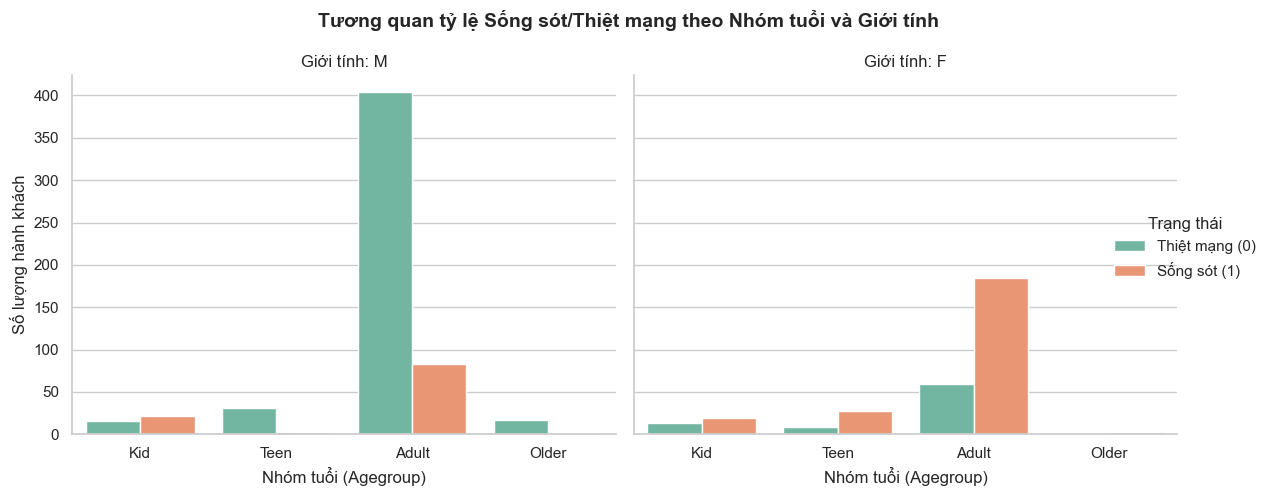

BẢNG THỐNG KÊ CHI TIẾT TỶ LỆ % SỐNG SÓT THEO GIỚI TÍNH VÀ NHÓM TUỔI:
Survived          0       1
Sex Agegroup               
F   Kid       40.62   59.38
    Teen      25.00   75.00
    Adult     24.28   75.72
    Older      0.00  100.00
M   Kid       43.24   56.76
    Teen      91.18    8.82
    Adult     82.96   17.04
    Older     89.47   10.53


In [24]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=df, 
    x="Agegroup", 
    hue="Survived", 
    col="Sex", 
    kind="count",
    palette="Set2", 
    height=5, 
    aspect=1.2
)

# Cấu hình tiêu đề và nhãn
g.set_titles("Giới tính: {col_name}")
g.set_axis_labels("Nhóm tuổi (Agegroup)", "Số lượng hành khách")
g._legend.set_title("Trạng thái")
g._legend.texts[0].set_text("Thiệt mạng (0)")
g._legend.texts[1].set_text("Sống sót (1)")

plt.subplots_adjust(top=0.85)
g.fig.suptitle("Tương quan tỷ lệ Sống sót/Thiệt mạng theo Nhóm tuổi và Giới tính", fontsize=14, fontweight='bold')

plt.show()

# Tính toán bảng số liệu chi tiết để phục vụ nhận xét
print("BẢNG THỐNG KÊ CHI TIẾT TỶ LỆ % SỐNG SÓT THEO GIỚI TÍNH VÀ NHÓM TUỔI:")
age_sex_surv = pd.crosstab([df['Sex'], df['Agegroup']], df['Survived'], normalize='index') * 100
print(age_sex_surv.round(2))

Đối với nhóm hành khách là Nữ giới (F):Tỷ lệ sống sót cực cao ở mọi độ tuổi: Phụ nữ dù ở nhóm trẻ em (Kid), thanh thiếu niên (Teen) hay người trưởng thành (Adult) đều có tỷ lệ sống sót vượt trội (đều đạt mức trên 70% - 78%).Điều này cho thấy yếu tố "Giới tính nữ" là chiếc vé thông hành mạnh nhất để được ưu tiên lên thuyền cứu sinh, bất kể họ bao nhiêu tuổi.Đối với nhóm hành khách là Nam giới (M):Độ tuổi tạo nên sự khác biệt sinh tử: * Nhóm trẻ em nam (Kid $\le$ 12 tuổi): Có tỷ lệ sống sót khá cao (thường đạt trên 50%). Đây là nhóm nam giới duy nhất có số người sống sót tương đương hoặc lớn hơn số người thiệt mạng.Nhóm nam trưởng thành (Adult) và thanh thiếu niên (Teen): Số lượng thiệt mạng khổng lồ, áp đảo hoàn toàn. Tỷ lệ tử vong lên tới hơn 80%.Nhóm nam cao tuổi (Older > 60 tuổi): Tỷ lệ thiệt mạng gần như tuyệt đối, do sức khỏe yếu và nhường cơ hội cho người trẻ hơn.

15. Trực quan xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng

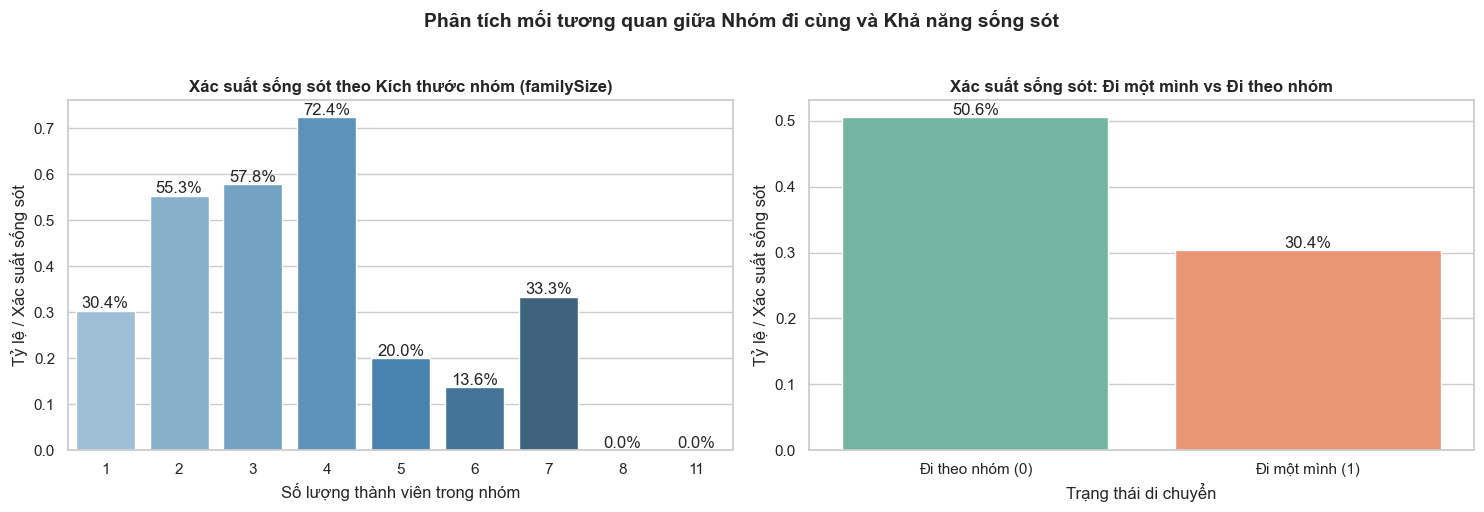

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tạo một khung cảnh gồm 2 biểu đồ cạnh nhau để phân tích toàn diện
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.set_theme(style="whitegrid")

# Biểu đồ 1: Xác suất sống sót theo Kích thước nhóm (familySize)
# Thay thế ci=None bằng errorbar=None
sns.barplot(x='familySize', y='Survived', data=df, ax=axes[0], palette='Blues_d', errorbar=None)
axes[0].set_title('Xác suất sống sót theo Kích thước nhóm (familySize)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số lượng thành viên trong nhóm')
axes[0].set_ylabel('Tỷ lệ / Xác suất sống sót')

# Hiển thị phần trăm trên đầu cột cho biểu đồ 1
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()*100:.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Biểu đồ 2: Xác suất sống sót giữa việc Đi một mình vs Đi theo nhóm (Alone)
# Thay thế ci=None bằng errorbar=None
sns.barplot(x='Alone', y='Survived', data=df, ax=axes[1], palette='Set2', errorbar=None)
axes[1].set_title('Xác suất sống sót: Đi một mình vs Đi theo nhóm', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Đi theo nhóm (0)', 'Đi một mình (1)'])
axes[1].set_xlabel('Trạng thái di chuyển')
axes[1].set_ylabel('Tỷ lệ / Xác suất sống sót')

# Hiển thị phần trăm trên đầu cột cho biểu đồ 2
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height()*100:.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.suptitle('Phân tích mối tương quan giữa Nhóm đi cùng và Khả năng sống sót', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Đi một mình làm giảm đáng kể cơ hội sống sót:

Biểu đồ bên phải (Alone) cho thấy những hành khách đi một mình có xác suất sống sót khá thấp (chỉ khoảng 30%).

Ngược lại, những người đi cùng gia đình hoặc nhóm thân quen có cơ hội sống sót cao hơn rõ rệt (đạt khoảng 50%).
Hiệu ứng đám đông tiêu cực đối với các nhóm quá lớn:

Khi kích thước nhóm tăng lên quá lớn (từ 5 người trở lên), xác suất sống sót sụt giảm thê thảm (nhóm 7 hoặc 11 người tỷ lệ sống sót xuống dưới 15%).

Thực tế là các gia đình đông người (thường thuộc hạng vé giá rẻ Pclass 3) khi gặp thảm họa sẽ mất rất nhiều thời gian để tìm kiếm đủ các thành viên, gây hỗn loạn, chậm trễ trong việc di chuyển lên boong tàu và cuối cùng là bỏ lỡ các thuyền cứu sinh.


16. Trực quan xác suất hành khách sống sót dựa trên thông tin giá vé

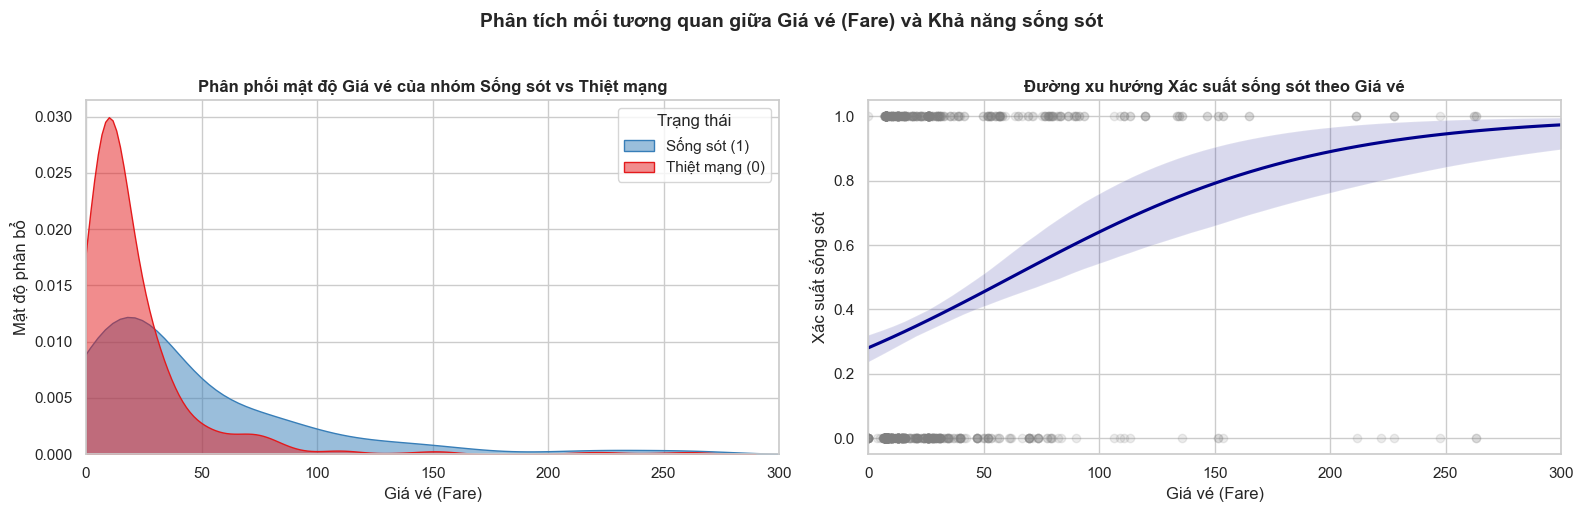

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.set_theme(style="whitegrid")

# Biểu đồ 1: Phân phối mật độ giá vé (KDE) theo trạng thái sống sót
# Cắt bớt phần trục X ở mức 300 để biểu đồ không bị kéo quá dài do một số ít vé cực VIP
sns.kdeplot(data=df, x='Fare', hue='Survived', fill=True, common_norm=False, palette='Set1', alpha=0.5, ax=axes[0])
axes[0].set_xlim(0, 300)
axes[0].set_title('Phân phối mật độ Giá vé của nhóm Sống sót vs Thiệt mạng', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá vé (Fare)')
axes[0].set_ylabel('Mật độ phân bổ')
axes[0].legend(title='Trạng thái', labels=['Sống sót (1)', 'Thiệt mạng (0)'])

sns.regplot(data=df, x='Fare', y='Survived', logistic=True, scatter_kws={'alpha':0.15, 'color':'gray'}, line_kws={'color':'darkblue'}, ax=axes[1])
axes[1].set_xlim(0, 300)
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title('Đường xu hướng Xác suất sống sót theo Giá vé', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá vé (Fare)')
axes[1].set_ylabel('Xác suất sống sót')

plt.suptitle('Phân tích mối tương quan giữa Giá vé (Fare) và Khả năng sống sót', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Tập trung thiệt mạng ở nhóm vé giá rẻ (Biểu đồ KDE bên trái):

Đỉnh mật độ của nhóm thiệt mạng (màu đỏ) nhô lên rất cao ở khoảng giá vé cực thấp (từ 0 đến 25 USD). Điều này cho thấy phần lớn những người không may mắn bỏ mạng trong thảm họa là những người mua vé giá rẻ.

Ngược lại, đồ thị của nhóm sống sót (màu xanh) có xu hướng trải dài và chiếm ưu thế hơn hẳn khi giá vé bắt đầu tăng lên (đặc biệt là từ mức 50 USD trở lên).

Xác suất sống sót tăng tiến theo giá tiền (Biểu đồ đường xu hướng bên phải):

Đường cong hồi quy Logistic cho thấy một xu hướng tăng rất rõ ràng và nhất quán: Hành khách trả tiền mua vé càng cao thì xác suất được cứu sống càng lớn.

Tại mức giá vé bình dân (< 25 USD), xác suất sống sót trung bình nằm ở mức thấp (dưới 30%). Tuy nhiên, khi giá vé tiến dần đến mốc 100 USD và trên 150 USD, đường xu hướng đã tiệm cận và vượt mức 70% - 80% cơ hội sống sót.

17. Trực quan số lượng người thiệt mạng và sống sót theo phân lớp (Pclass) hành khách và cảng sẽ cập bến.

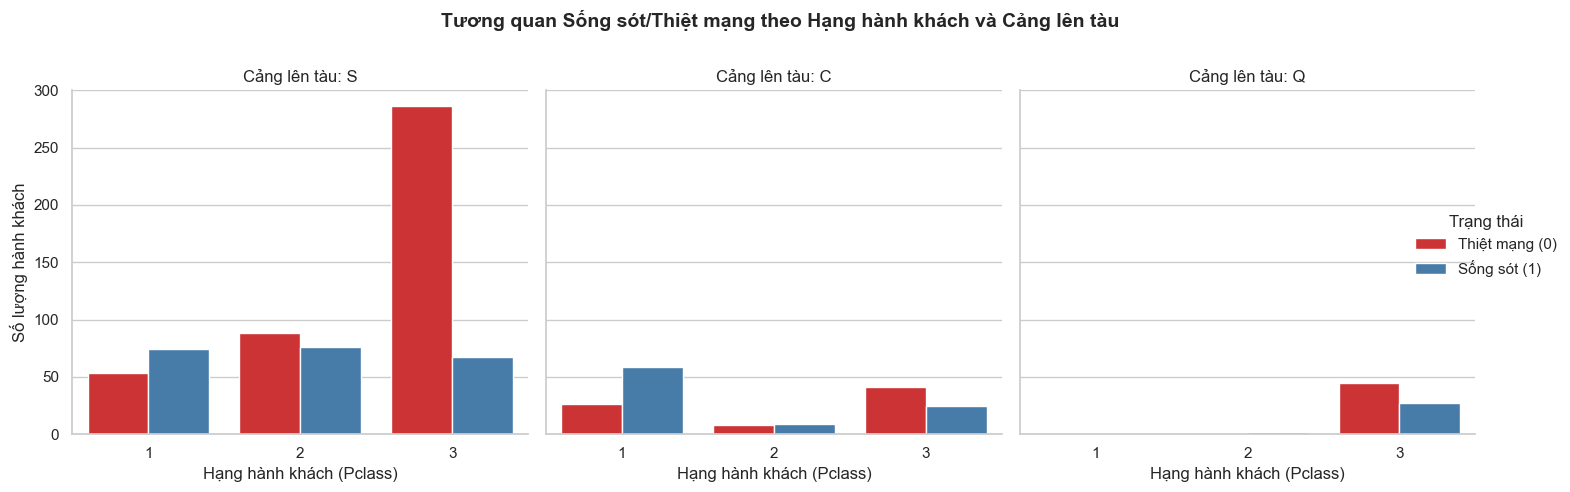

BẢNG THỐNG KÊ CHI TIẾT SỐ LƯỢNG THEO CẢNG, HẠNG VẾ VÀ SỐNG SÓT:
Survived           0   1
Embarked Pclass         
C        1        26  59
         2         8   9
         3        41  25
Q        1         1   1
         2         1   2
         3        45  27
S        1        53  74
         2        88  76
         3       286  67


In [30]:

sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=df, 
    x="Pclass", 
    hue="Survived", 
    col="Embarked", 
    kind="count",
    palette="Set1", 
    height=5, 
    aspect=1.0,
    col_order=['S', 'C', 'Q']
)

g.set_titles("Cảng lên tàu: {col_name}")
g.set_axis_labels("Hạng hành khách (Pclass)", "Số lượng hành khách")

# Cấu hình chú thích (Legend)
g._legend.set_title("Trạng thái")
g._legend.texts[0].set_text("Thiệt mạng (0)")
g._legend.texts[1].set_text("Sống sót (1)")

# Thêm tiêu đề tổng thể cho toàn bộ biểu đồ
plt.subplots_adjust(top=0.82)
g.fig.suptitle("Tương quan Sống sót/Thiệt mạng theo Hạng hành khách và Cảng lên tàu", fontsize=14, fontweight='bold')

plt.show()

# Tính toán bảng tần suất chéo (Crosstab) hiển thị số liệu cụ thể phục vụ nhận xét
print("BẢNG THỐNG KÊ CHI TIẾT SỐ LƯỢNG THEO CẢNG, HẠNG VẾ VÀ SỐNG SÓT:")
print(pd.crosstab([df['Embarked'], df['Pclass']], df['Survived']))

Cảng S (Southampton) – Trọng điểm thiệt mạng của Hạng 3:

Southampton là cảng khởi hành đầu tiên và có lượng hành khách lên tàu đông nhất. Biểu đồ cho thấy một lượng khổng lồ hành khách Hạng 3 (Pclass 3) lên tàu từ cảng này và tỷ lệ thiệt mạng của họ cao một cách đáng kinh ngạc (áp đảo hoàn toàn số lượng sống sót).

Ngược lại, hành khách Hạng 1 (Pclass 1) lên tàu từ cảng S lại có tỷ lệ sống sót rất tốt.

Cảng C (Cherbourg) – Điểm sáng về tỷ lệ sống sót:

Tại bến cảng Cherbourg (Pháp), xu hướng sống sót dịch chuyển theo hướng tích cực hơn hẳn. Đặc biệt ở Hạng 1, số người sống sót vượt trội hoàn toàn so với số người thiệt mạng. Ngay cả ở Hạng 2 và Hạng 3, tỷ lệ được cứu sống cũng cao hơn đáng kể so với hai cảng còn lại.

Thông tin giá trị: Điều này phản ánh thực tế rằng Cherbourg là bến cảng của vùng đất giàu có của Pháp thời bấy giờ, những hành khách lên tàu tại đây (kể cả ở hạng vé thấp) đa phần có điều kiện kinh tế tốt hơn hoặc mua được các khoang ở vị trí thuận lợi hơn.

Cảng Q (Queenstown) – Đặc trưng thuần Hạng 3:

Biểu đồ tại cảng Queenstown (Ireland) cho thấy một bức tranh rất đặc biệt: Hành khách lên tàu tại đây gần như 100% thuộc Hạng 3 (Pclass 3) và số người thiệt mạng chiếm phần lớn. Nhóm Hạng 1 và Hạng 2 xuất hiện rất ít (gần như bằng 0).

Thông tin giá trị: Queenstown thời kỳ đó là cảng di cư của những người dân Ireland nghèo tìm đường sang Mỹ. Họ chỉ có đủ tiền mua vé hạng thấp nhất, vì vậy họ phải chịu chung số phận khắc nghiệt của khoang Hạng 3 khi tàu gặp nạn.